# 10 — LoRA Inference: Config G

**Config G = SD Inpainting + LoRA(r=8) + ControlNet-Canny + IP-Adapter Plus**  
Full stack future work — kết hợp cả 3: domain adaptation + shape prior + surface prior.

```
Ablation chain:
  A: SD only
  B: SD + ControlNet
  C: SD + ControlNet + IP-Adapter
  E: SD + LoRA
  F: SD + LoRA + CN
  G: SD + LoRA + CN + IP  ← BẠN Ở ĐÂY (future work)
```

```
project_root/
├── data/synthetic_occ/
├── outputs/
│   ├── lora_weights/r8/best/   ← từ notebook 07
│   └── lora_sd_cn_ip/          ← Config G output
│       ├── x_hat/
│       ├── eval_gt_200/
│       ├── eval_pred_200/
│       └── reports/
```

**Chạy sau:** notebook 07  
**Chạy trước:** re-run notebook 05 → 06

In [1]:
# CELL 1 — Dependencies
import sys
!{sys.executable} -m pip install -q \
    "diffusers>=0.27.0" "peft>=0.8.0" "accelerate>=0.26.0" \
    "transformers>=4.36.0" scikit-image lpips clean-fid opencv-python scikit-learn
print("Dependencies ready")

Dependencies ready


In [2]:
# CELL 2 — Config & Paths
import random, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import cv2
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SYNTH_DIR = PROJECT_ROOT / "data" / "synthetic_occ"
GT_DIR    = SYNTH_DIR / "x_gt"
OCC_DIR   = SYNTH_DIR / "x_occ"
MASK_DIR  = SYNTH_DIR / "masks"
META_CSV  = SYNTH_DIR / "metadata_synthetic_occ.csv"
EVAL_CSV  = PROJECT_ROOT / "outputs" / "eval" / "metrics_per_image_A_SD_only.csv"

LORA_WEIGHTS = PROJECT_ROOT / "outputs" / "lora_weights" / "r8" / "best"
TRAIN_CFG    = PROJECT_ROOT / "outputs" / "lora_weights" / "r8" / "training_config.json"

SD_MODEL_ID  = "runwayml/stable-diffusion-inpainting"
CN_MODEL_ID  = "lllyasviel/control_v11p_sd15_canny"
IP_REPO      = "h94/IP-Adapter"
IP_SUBFOLDER = "models"
IP_WEIGHT    = "ip-adapter-plus_sd15.bin"

# Output dir Config G
LORA_SD_CN_IP_DIR = PROJECT_ROOT / "outputs" / "lora_sd_cn_ip"
PRED_DIR          = LORA_SD_CN_IP_DIR / "x_hat"
EVAL_GT_DIR       = LORA_SD_CN_IP_DIR / "eval_gt_200"
EVAL_PRED_DIR     = LORA_SD_CN_IP_DIR / "eval_pred_200"
REPORT_DIR        = LORA_SD_CN_IP_DIR / "reports"
for d in [PRED_DIR, EVAL_GT_DIR, EVAL_PRED_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Dirs so sánh chart
XHAT_A = PROJECT_ROOT / "outputs" / "baseline_sd2"      / "x_hat"
XHAT_C = PROJECT_ROOT / "outputs" / "controlnet_ip_sd"  / "x_hat"
XHAT_E = PROJECT_ROOT / "outputs" / "lora_sd"           / "x_hat"
XHAT_F = PROJECT_ROOT / "outputs" / "lora_sd_cn"        / "x_hat"

PROMPT         = "a car, realistic, high quality, detailed"
NEG_PROMPT     = "blurry, distorted, artifacts"
NUM_STEPS      = 20
GUIDANCE       = 7.5
TEST_SIZE      = 200
CANNY_LOW      = 80
CANNY_HIGH     = 150
MASK_DILATE_PX = 5
CN_SCALE_GRID  = [0.25, 0.40, 0.55]
IP_SCALE_GRID  = [0.3, 0.5, 0.7]
GRID_SAMPLE    = 15

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32

assert SYNTH_DIR.exists(), f"Dataset không tìm thấy: {SYNTH_DIR}"
if not LORA_WEIGHTS.exists():
    raise FileNotFoundError(f"LoRA weights không tìm thấy: {LORA_WEIGHTS}\n→ Chạy 07 trước!")

train_cfg = json.loads(TRAIN_CFG.read_text()) if TRAIN_CFG.exists() else {}
lora_rank = train_cfg.get("lora_rank", 8)
meta      = pd.read_csv(META_CSV)
meta.columns = meta.columns.str.strip().str.lower()

print(f"Device       : {DEVICE}")
print(f"Project root : {PROJECT_ROOT}")
print(f"LoRA weights : {LORA_WEIGHTS}  (r={lora_rank})")
print(f"IP-Adapter   : {IP_REPO}/{IP_SUBFOLDER}/{IP_WEIGHT}")
print(f"Output       : {LORA_SD_CN_IP_DIR}")
print(f"Config G     : SD + LoRA(r={lora_rank}) + ControlNet-Canny + IP-Adapter Plus")
print(f"Metadata     : {len(meta):,} rows")

Device       : cuda
Project root : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus
LoRA weights : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r8\best  (r=8)
IP-Adapter   : h94/IP-Adapter/models/ip-adapter-plus_sd15.bin
Output       : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn_ip
Config G     : SD + LoRA(r=8) + ControlNet-Canny + IP-Adapter Plus
Metadata     : 11,254 rows


In [3]:
# CELL 3 — Load Pipeline Config G
# SD + LoRA(r=8) fused + ControlNet-Canny + IP-Adapter Plus
# Không xformers
from diffusers import (
    StableDiffusionControlNetInpaintPipeline,
    ControlNetModel,
    DPMSolverMultistepScheduler,
)
from peft import PeftModel

print("Loading ControlNet...")
controlnet = ControlNetModel.from_pretrained(CN_MODEL_ID, torch_dtype=DTYPE)

print("Loading SD Inpainting + ControlNet pipeline...")
pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
    SD_MODEL_ID, controlnet=controlnet,
    torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False,
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

print(f"Loading & fusing LoRA r={lora_rank}...")
pipe.unet = PeftModel.from_pretrained(pipe.unet, str(LORA_WEIGHTS))
pipe.unet = pipe.unet.merge_and_unload()
print("LoRA fused.")

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing("auto")
pipe.vae.enable_slicing()

# Load IP-Adapter Plus
USE_IP_ADAPTER = False
try:
    print("Loading IP-Adapter Plus...")
    pipe.load_ip_adapter(IP_REPO, subfolder=IP_SUBFOLDER, weight_name=IP_WEIGHT)
    USE_IP_ADAPTER = True
    print("IP-Adapter Plus loaded.")
except Exception as e:
    print(f"⚠  IP-Adapter load failed: {e}")
    print("   Fallback: chạy không có IP-Adapter (text color prompt).")

config_label = "G_LoRA_CN_IP" if USE_IP_ADAPTER else "G_LoRA_CN_TextColor"
print(f"\nPipeline ready — {config_label}")
print(f"  LoRA r={lora_rank} fused  : True")
print(f"  ControlNet        : True")
print(f"  IP-Adapter        : {USE_IP_ADAPTER}")
print(f"  Scheduler         : {pipe.scheduler.__class__.__name__}")

c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading ControlNet...
Loading SD Inpainting + ControlNet pipeline...


vae\diffusion_pytorch_model.safetensors not found
Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  17%|█▋        | 1/6 [00:04<00:20,  4.11s/it]c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details ch

Loading & fusing LoRA r=8...
LoRA fused.
Loading IP-Adapter Plus...
IP-Adapter Plus loaded.

Pipeline ready — G_LoRA_CN_IP
  LoRA r=8 fused  : True
  ControlNet        : True
  IP-Adapter        : True
  Scheduler         : DPMSolverMultistepScheduler


In [4]:
# CELL 4 — Helper Functions
from skimage.metrics import structural_similarity as ssim_fn
import lpips as lpips_lib

lpips_model = lpips_lib.LPIPS(net="alex").to(DEVICE).eval()


def extract_canny_masked(image_pil, mask_pil,
                         low=CANNY_LOW, high=CANNY_HIGH, dilate_px=MASK_DILATE_PX):
    img   = np.array(image_pil.convert("RGB"))
    edges = cv2.Canny(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), low, high)
    msk   = np.array(mask_pil.convert("L"))
    if dilate_px > 0:
        k   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_px*2+1, dilate_px*2+1))
        msk = cv2.dilate(msk, k, iterations=1)
    edges[msk > 127] = 0
    return Image.fromarray(np.stack([edges]*3, axis=2))


def extract_visible_patch(image_pil, mask_pil):
    img     = np.array(image_pil.convert("RGB"))
    msk     = np.array(mask_pil.convert("L"))
    visible = msk < 128
    mean_c  = img[visible].mean(axis=0).astype(np.uint8) if visible.sum() > 0 \
              else np.array([128,128,128], dtype=np.uint8)
    patch   = img.copy(); patch[~visible] = mean_c
    return Image.fromarray(patch)


def get_color_prompt(image_pil, mask_pil):
    from sklearn.cluster import KMeans
    img = np.array(image_pil.convert("RGB"))
    msk = np.array(mask_pil.convert("L"))
    px  = img[msk < 128]
    if len(px) < 100: return PROMPT
    km  = KMeans(n_clusters=3, random_state=SEED, n_init=10)
    km.fit(px.reshape(-1, 3))
    labels, counts = np.unique(km.labels_, return_counts=True)
    rgb = km.cluster_centers_[labels[np.argmax(counts)]].astype(np.uint8)
    hsv = cv2.cvtColor(np.uint8([[rgb]]), cv2.COLOR_RGB2HSV)[0, 0]
    h, s, v = int(hsv[0]), int(hsv[1]), int(hsv[2])
    if   v < 50:             name = "black"
    elif s < 30 and v > 200: name = "white"
    elif s < 40:             name = "silver" if v > 140 else "gray"
    elif h < 10 or h > 170:  name = "red"
    elif h < 25:             name = "orange"
    elif h < 35:             name = "yellow"
    elif h < 85:             name = "green"
    elif h < 130:            name = "blue"
    elif h < 160:            name = "purple"
    else:                    name = "red"
    return f"a {name} car, realistic, high quality, detailed, consistent paint color"


def masked_ssim(gt, pred, m):
    _, smap = ssim_fn(gt/255., pred/255., channel_axis=2, data_range=1.0, full=True)
    return float(smap[m.astype(bool)].mean()) if m.sum() > 0 else float(smap.mean())


def masked_lpips(gt, pred, m):
    mf   = m.astype(np.float32)[..., None]
    gt_t = torch.from_numpy((gt*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    pr_t = torch.from_numpy((pred*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    with torch.no_grad():
        return float(lpips_model(gt_t.to(DEVICE), pr_t.to(DEVICE)).item())


def inpaint_g(image, mask, prompt, cn_scale=0.4, ip_scale=0.5, seed=SEED):
    """Config G: LoRA(fused) + ControlNet-Canny + IP-Adapter (hoặc text fallback)."""
    canny = extract_canny_masked(image, mask)
    gen   = torch.Generator(device=DEVICE).manual_seed(seed)
    kwargs = dict(
        prompt=prompt, negative_prompt=NEG_PROMPT,
        image=image, control_image=canny, mask_image=mask,
        num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE,
        controlnet_conditioning_scale=cn_scale, generator=gen,
    )
    if USE_IP_ADAPTER:
        pipe.set_ip_adapter_scale(ip_scale)
        kwargs["ip_adapter_image"] = extract_visible_patch(image, mask)
    else:
        kwargs["prompt"] = get_color_prompt(image, mask)
    if DEVICE == "cuda":
        with torch.autocast("cuda"):
            out = pipe(**kwargs).images[0]
    else:
        out = pipe(**kwargs).images[0]
    return out


print(f"Helper functions defined — {config_label}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\weights\v0.1\alex.pth
Helper functions defined — G_LoRA_CN_IP


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_lo

In [5]:
# CELL 5 — Grid Search cn_scale × ip_scale  (non-test pool)
from tqdm.auto import tqdm

if EVAL_CSV.exists():
    test_stems = set(pd.read_csv(EVAL_CSV)["stem"].tolist())
else:
    test_stems = set(meta.sample(TEST_SIZE, random_state=SEED)["stem"].tolist())
    print("⚠  eval CSV không tìm thấy — reproduced test split")

non_test  = meta[~meta["stem"].isin(test_stems)].reset_index(drop=True)
grid_pool = non_test.sample(min(GRID_SAMPLE, len(non_test)), random_state=SEED).reset_index(drop=True)

ip_values  = IP_SCALE_GRID if USE_IP_ADAPTER else [0.0]
print(f"Grid: {len(CN_SCALE_GRID)}×{len(ip_values)} combos × {len(grid_pool)} ảnh")

grid_res = []
for cn_s in CN_SCALE_GRID:
    for ip_s in ip_values:
        ss, lp = [], []
        tag = f"cn={cn_s:.2f},ip={ip_s:.1f}" if USE_IP_ADAPTER else f"cn={cn_s:.2f}"
        for _, r in tqdm(grid_pool.iterrows(), total=len(grid_pool), desc=tag, leave=False):
            occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512,512))
            msk  = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512,512))
            gt   = Image.open(GT_DIR   / r["x_gt"]).convert("RGB").resize((512,512))
            pred = inpaint_g(occ, msk, PROMPT, cn_scale=cn_s, ip_scale=ip_s)
            mk01 = (cv2.resize(
                cv2.imread(str(MASK_DIR/f"{r['stem']}.png"), cv2.IMREAD_GRAYSCALE),
                (512,512)) > 127).astype(np.uint8)
            ss.append(masked_ssim(np.array(gt), np.array(pred), mk01))
            lp.append(masked_lpips(np.array(gt), np.array(pred), mk01))
        grid_res.append({"cn_scale": cn_s, "ip_scale": ip_s,
                         "ssim_mean": float(np.mean(ss)), "lpips_mean": float(np.mean(lp))})
        print(f"  {tag}  SSIM={np.mean(ss):.4f}  LPIPS={np.mean(lp):.4f}")

grid_df  = pd.DataFrame(grid_res)
best_idx = grid_df["lpips_mean"].idxmin()
BEST_CN  = float(grid_df.loc[best_idx, "cn_scale"])
BEST_IP  = float(grid_df.loc[best_idx, "ip_scale"])
grid_df.to_csv(REPORT_DIR / "grid_search.csv", index=False)
print(f"\nBest: cn_scale={BEST_CN}, ip_scale={BEST_IP}")
print(grid_df.to_string(index=False))

⚠  eval CSV không tìm thấy — reproduced test split
Grid: 3×3 combos × 15 ảnh


100%|██████████| 20/20 [00:04<00:00,  4.54it/s]0:04,  4.94s/it]


  cn=0.25,ip=0.3  SSIM=0.6119  LPIPS=0.0511


100%|██████████| 20/20 [00:04<00:00,  4.49it/s]0:04,  4.95s/it]


  cn=0.25,ip=0.5  SSIM=0.6080  LPIPS=0.0514


...

  cn=0.55,ip=0.3  SSIM=0.6092  LPIPS=0.0526


100%|██████████| 20/20 [00:04<00:00,  4.38it/s]0:05,  5.12s/it]


  cn=0.55,ip=0.5  SSIM=0.6060  LPIPS=0.0540


100%|██████████| 20/20 [00:04<00:00,  4.38it/s]0:05,  5.11s/it]
                                                               

  cn=0.55,ip=0.7  SSIM=0.6025  LPIPS=0.0545

Best: cn_scale=0.25, ip_scale=0.3
 cn_scale  ip_scale  ssim_mean  lpips_mean
     0.25       0.3   0.611924    0.051075
     0.25       0.5   0.608036    0.051377
     0.25       0.7   0.603378    0.052744
     0.40       0.3   0.609885    0.051618
     0.40       0.5   0.609397    0.052051
     0.40       0.7   0.602860    0.053184
     0.55       0.3   0.609241    0.052584
     0.55       0.5   0.606029    0.053992
     0.55       0.7   0.602505    0.054530


In [6]:
# CELL 6 — Full Inference 200 ảnh
test_df = meta.sample(TEST_SIZE, random_state=SEED).reset_index(drop=True)
print(f"Test set: {len(test_df)} ảnh | cn={BEST_CN}, ip={BEST_IP}")

pred_records = []
t0 = time.time()

for idx, r in tqdm(test_df.iterrows(), total=len(test_df), desc="Config G inference"):
    occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512,512))
    msk  = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512,512))
    gt   = Image.open(GT_DIR   / r["x_gt"]).convert("RGB").resize((512,512))
    pred = inpaint_g(occ, msk, PROMPT, cn_scale=BEST_CN, ip_scale=BEST_IP)
    name = f"{r['stem']}.png"
    pred.save(PRED_DIR / name)
    gt.save(EVAL_GT_DIR / name)
    pred.save(EVAL_PRED_DIR / name)
    pred_records.append({
        "stem": r["stem"], "x_gt": r["x_gt"], "x_occ": r["x_occ"],
        "occlusion_ratio": r["occlusion_ratio"], "pred": name,
    })

infer_elapsed = time.time() - t0
pred_df = pd.DataFrame(pred_records)
print(f"Inference done: {len(pred_df)} ảnh trong {infer_elapsed/60:.1f} min")

Test set: 200 ảnh | cn=0.25, ip=0.3


Config G inference: 100%|██████████| 200/200 [16:57<00:00,  5.09s/it]

Inference done: 200 ảnh trong 17.0 min


In [7]:
# CELL 7 — Metrics (SSIM / LPIPS / FID)
from cleanfid import fid

metric_rows = []
for _, r in tqdm(pred_df.iterrows(), total=len(pred_df), desc="Metrics"):
    gt   = cv2.cvtColor(cv2.imread(str(GT_DIR   / r["x_gt"])),  cv2.COLOR_BGR2RGB)
    pr   = cv2.cvtColor(cv2.imread(str(PRED_DIR / r["pred"])), cv2.COLOR_BGR2RGB)
    gt   = cv2.resize(gt, (512,512)); pr = cv2.resize(pr, (512,512))
    mk01 = (cv2.resize(
        cv2.imread(str(MASK_DIR/f"{r['stem']}.png"), cv2.IMREAD_GRAYSCALE),
        (512,512)) > 127).astype(np.uint8)
    metric_rows.append({
        "stem": r["stem"], "occlusion_ratio": r["occlusion_ratio"],
        "ssim": masked_ssim(gt, pr, mk01), "lpips": masked_lpips(gt, pr, mk01),
    })

metric_df = pd.DataFrame(metric_rows)
print("Computing FID...")
fid_value = fid.compute_fid(str(EVAL_GT_DIR), str(EVAL_PRED_DIR), mode="clean", num_workers=0)

summary = {
    "config"             : config_label,
    "model"              : f"{SD_MODEL_ID} + LoRA(r={lora_rank}) + {CN_MODEL_ID} + {IP_WEIGHT}",
    "scheduler"          : pipe.scheduler.__class__.__name__,
    "num_test_images"    : int(len(metric_df)),
    "steps"              : int(NUM_STEPS), "guidance": float(GUIDANCE),
    "cn_scale"           : float(BEST_CN), "ip_scale": float(BEST_IP),
    "lora_rank"          : int(lora_rank),
    "lora_best_val_loss" : float(train_cfg.get("best_val_loss", 0)),
    "use_controlnet"     : True, "use_ip_adapter": USE_IP_ADAPTER,
    "ssim_mean"          : float(metric_df["ssim"].mean()),
    "lpips_mean"         : float(metric_df["lpips"].mean()),
    "fid"                : float(fid_value),
    "inference_minutes"  : float(infer_elapsed / 60),
    "xformers": False, "attention_slicing": True,
}

metric_df.to_csv(REPORT_DIR / f"{config_label}_metrics_per_image.csv", index=False)
pd.DataFrame([summary]).to_csv(REPORT_DIR / f"{config_label}_summary.csv", index=False)

print("=" * 55)
print(f"Config G ({config_label}):")
print(f"  SSIM  mean : {summary['ssim_mean']:.4f}")
print(f"  LPIPS mean : {summary['lpips_mean']:.4f}")
print(f"  FID        : {summary['fid']:.2f}")
print(f"  cn={BEST_CN}, ip={BEST_IP}")
print("=" * 55)

Metrics: 100%|██████████| 200/200 [00:35<00:00,  5.60it/s]


Computing FID...
compute FID between two folders
Found 400 images in the folder D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn_ip\eval_gt_200


FID eval_gt_200 : 100%|██████████| 13/13 [00:13<00:00,  1.04s/it]


Found 400 images in the folder D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn_ip\eval_pred_200


FID eval_pred_200 : 100%|██████████| 13/13 [00:12<00:00,  1.00it/s]


Config G (G_LoRA_CN_IP):
  SSIM  mean : 0.5956
  LPIPS mean : 0.0563
  FID        : 21.67
  cn=0.25, ip=0.3


In [8]:
# CELL 8 — Xuất ablation_row_G.csv
ablation_row = {
    "config"             : config_label,
    "model"              : summary["model"],
    "SSIM"               : summary["ssim_mean"],
    "LPIPS"              : summary["lpips_mean"],
    "FID"                : summary["fid"],
    "num_test"           : summary["num_test_images"],
    "steps"              : summary["steps"],
    "guidance"           : summary["guidance"],
    "scheduler"          : summary["scheduler"],
    "cn_scale"           : summary["cn_scale"],
    "ip_scale"           : summary["ip_scale"],
    "lora_rank"          : summary["lora_rank"],
    "lora_best_val_loss" : summary["lora_best_val_loss"],
    "use_controlnet"     : True, "use_ip_adapter": USE_IP_ADAPTER,
}
pd.DataFrame([ablation_row]).to_csv(REPORT_DIR / "ablation_row_G.csv", index=False)
print(f"Saved: {REPORT_DIR}/ablation_row_G.csv")
print()
print("─── Tích hợp vào notebook 05 ───")
print(f"  G_REPORT_DIR = Path('{REPORT_DIR}')")
print(f"  g_pi = G_REPORT_DIR / '{config_label}_metrics_per_image.csv'")
print( "  if g_pi.exists():")
print(f"      PER_IMAGE_SRC['{config_label}'] = g_pi")
print(f"      SUMMARY_SRC['{config_label}']   = G_REPORT_DIR / '{config_label}_summary.csv'")
print(f"      XHAT_DIRS['{config_label}']     = Path('{PRED_DIR}')")
print(f"      ACTIVE.append('{config_label}')")

Saved: D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn_ip\reports/ablation_row_G.csv

─── Tích hợp vào notebook 05 ───
  G_REPORT_DIR = Path('D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn_ip\reports')
  g_pi = G_REPORT_DIR / 'G_LoRA_CN_IP_metrics_per_image.csv'
  if g_pi.exists():
      PER_IMAGE_SRC['G_LoRA_CN_IP'] = g_pi
      SUMMARY_SRC['G_LoRA_CN_IP']   = G_REPORT_DIR / 'G_LoRA_CN_IP_summary.csv'
      XHAT_DIRS['G_LoRA_CN_IP']     = Path('D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn_ip\x_hat')
      ACTIVE.append('G_LoRA_CN_IP')


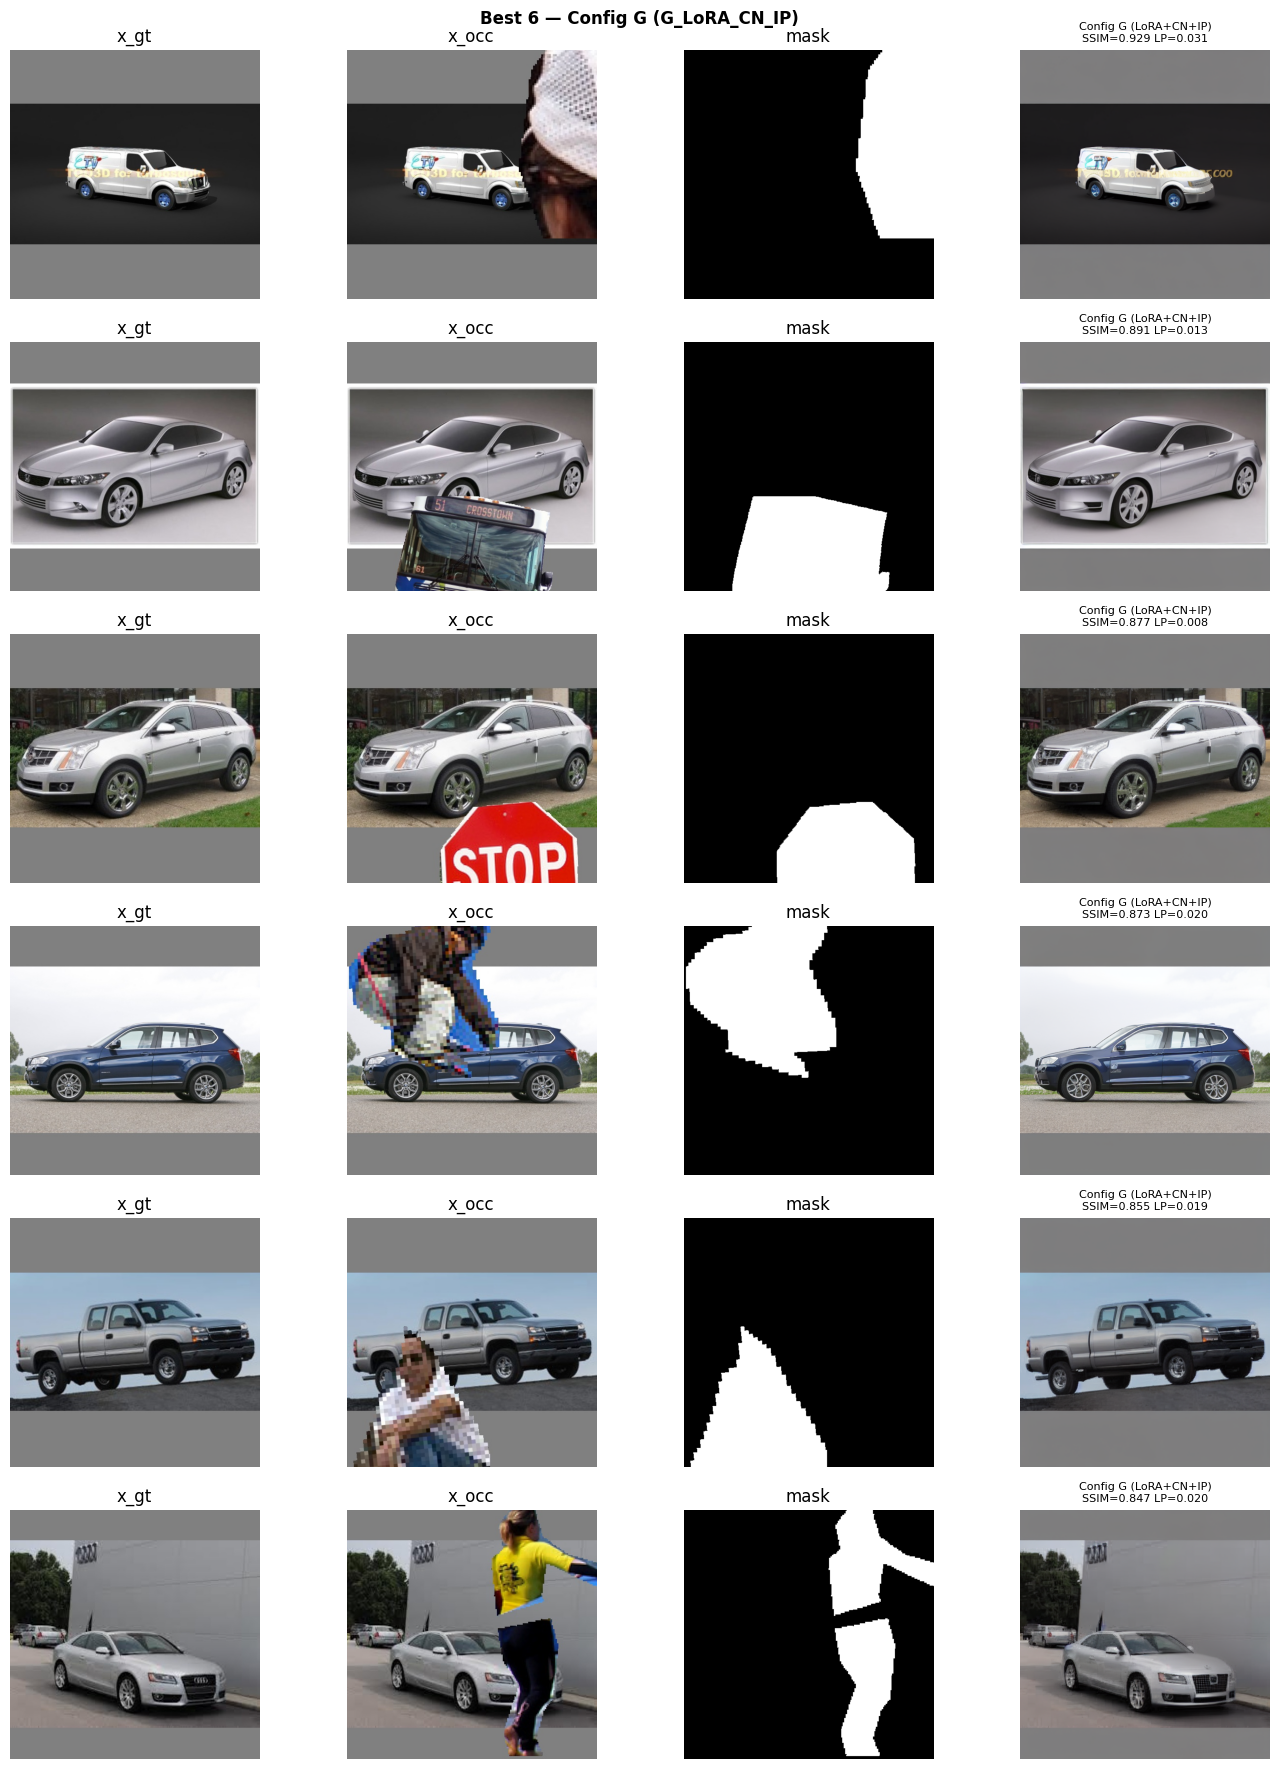

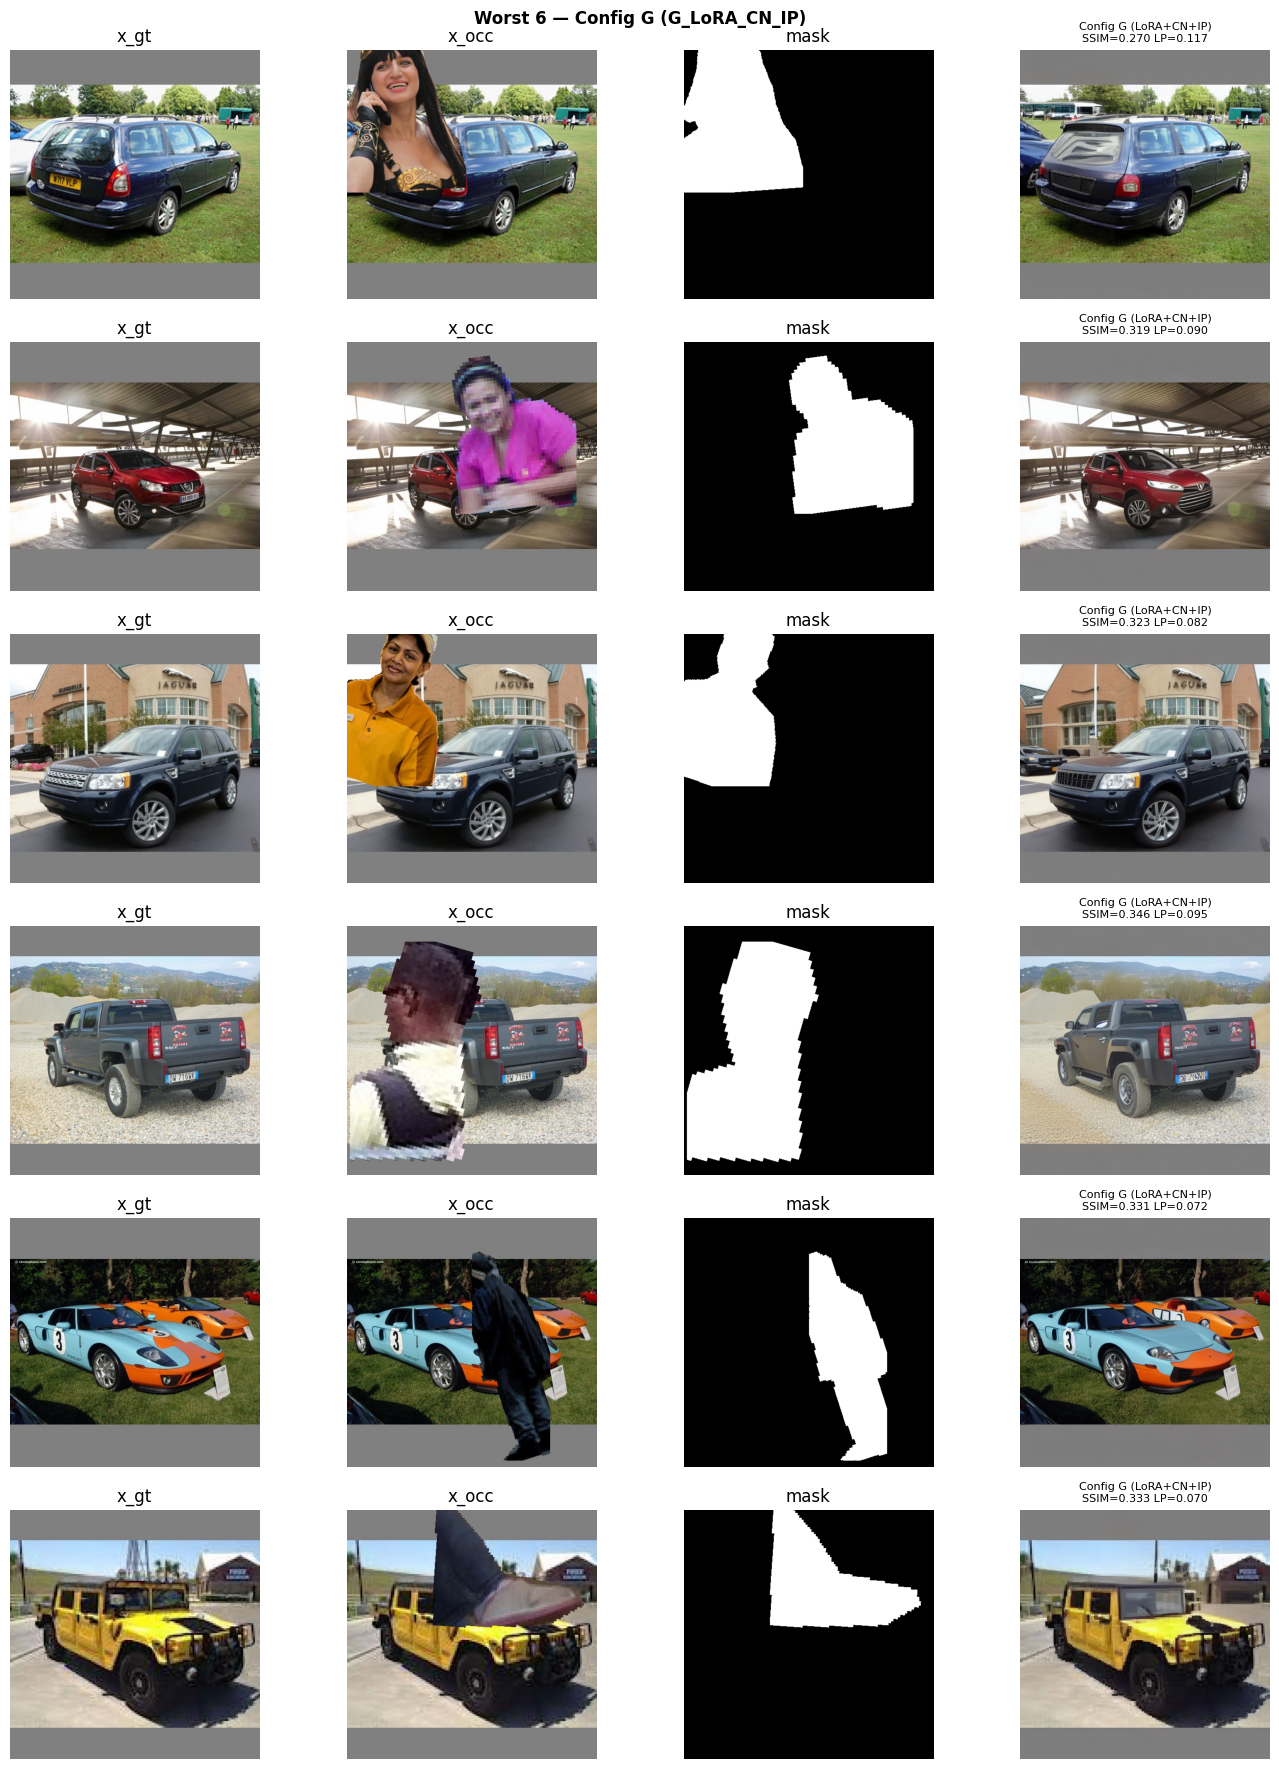

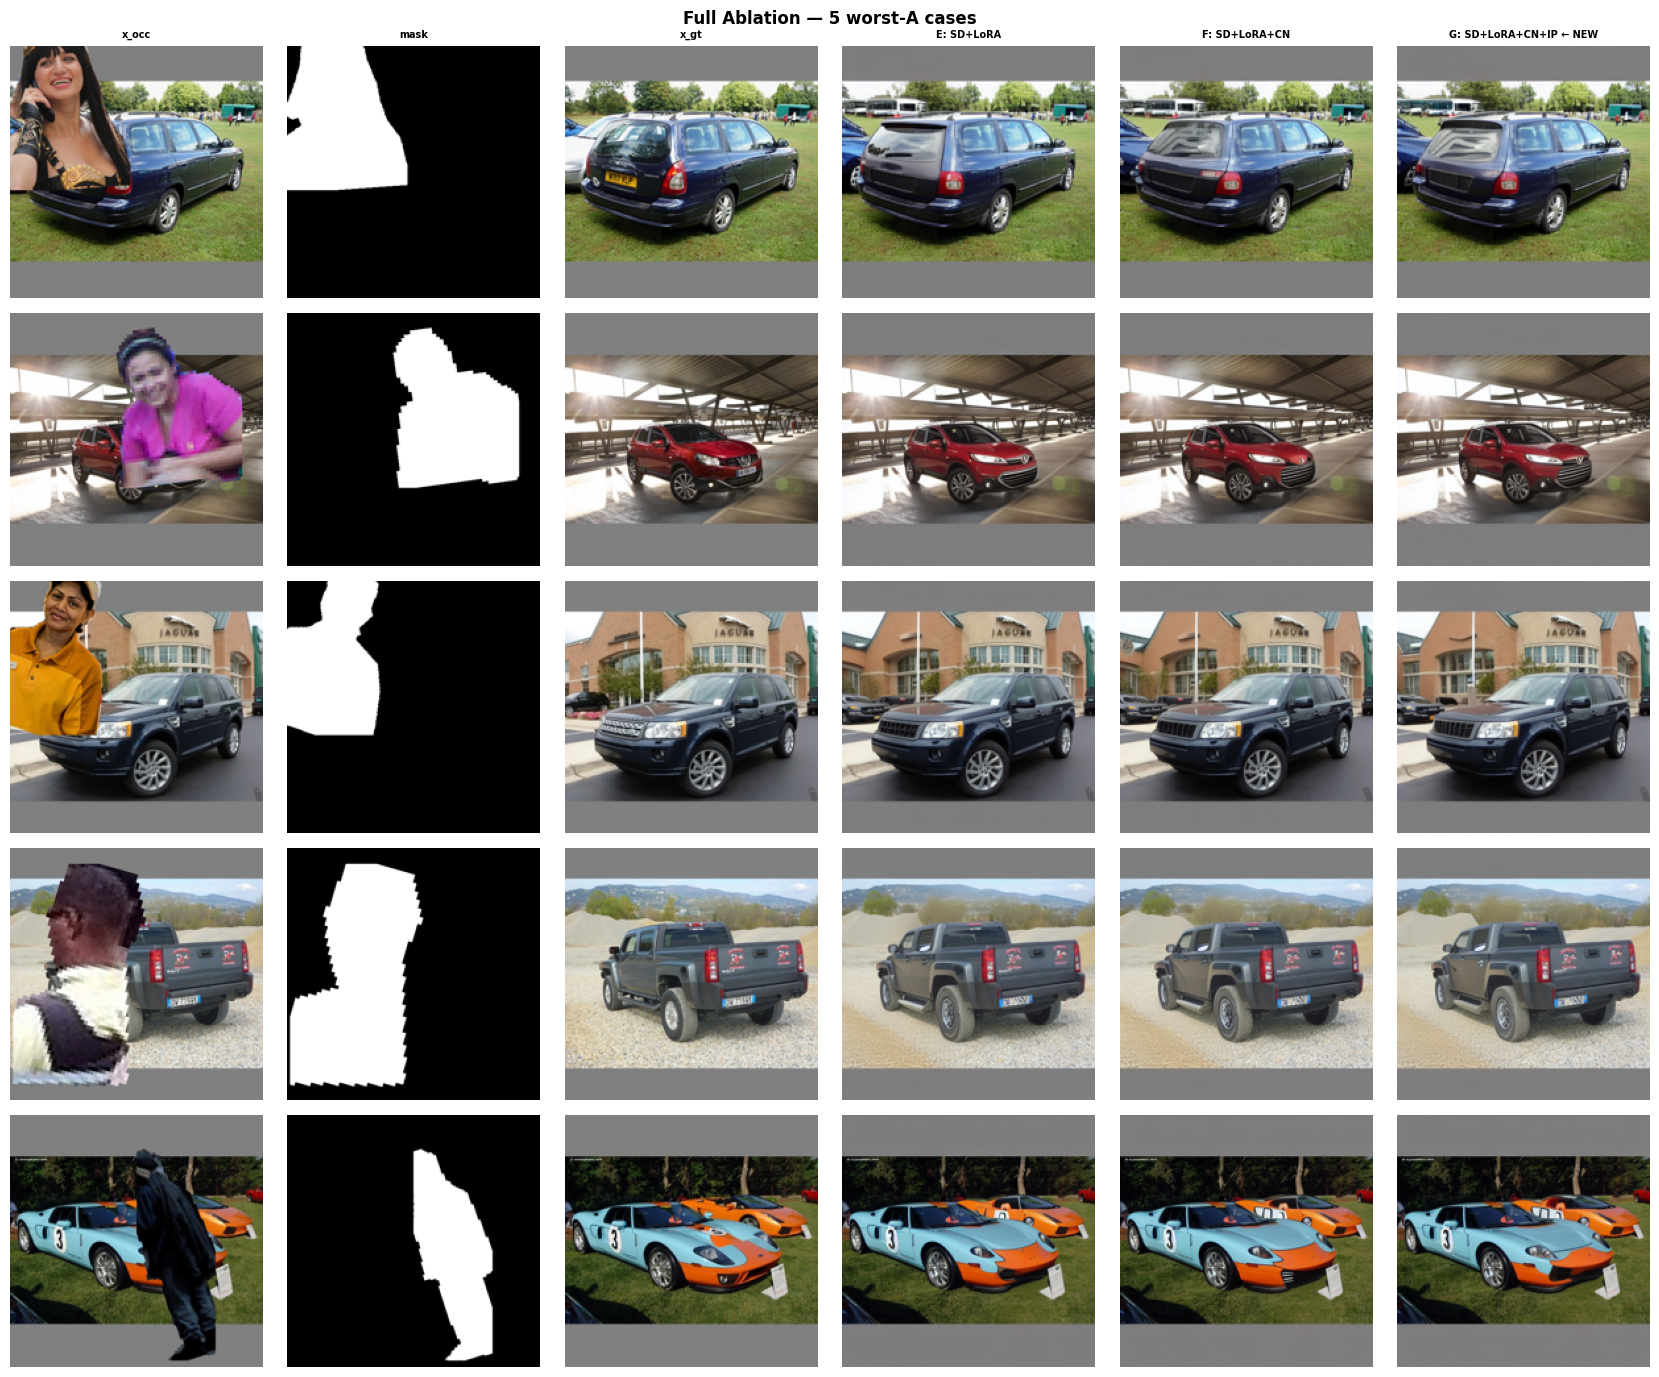

Saved: D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd_cn_ip\reports/comparison_full_ablation.png


In [9]:
# CELL 9 — Visualize Best / Worst + Full comparison A→G
import matplotlib.pyplot as plt

analysis_df = metric_df.copy()
analysis_df["score"] = analysis_df["ssim"] - analysis_df["lpips"]
best20  = analysis_df.sort_values("score", ascending=False).head(20)
worst20 = analysis_df.sort_values("score", ascending=True).head(20)
best20.to_csv(REPORT_DIR / "best20_cases.csv",  index=False)
worst20.to_csv(REPORT_DIR / "worst20_cases.csv", index=False)


def show_cases(case_df, title, n=6):
    n = min(n, len(case_df))
    fig, axes = plt.subplots(n, 4, figsize=(14, 3*n))
    if n == 1: axes = np.expand_dims(axes, 0)
    for i, (_, row) in enumerate(case_df.head(n).iterrows()):
        stem = row["stem"]
        rr   = pred_df[pred_df["stem"]==stem].iloc[0]
        gt   = Image.open(EVAL_GT_DIR   / f"{stem}.png").convert("RGB")
        pr   = Image.open(EVAL_PRED_DIR / f"{stem}.png").convert("RGB")
        occ  = Image.open(OCC_DIR / rr["x_occ"]).convert("RGB")
        msk  = Image.open(MASK_DIR / f"{stem}.png").convert("L")
        axes[i,0].imshow(gt);               axes[i,0].set_title("x_gt")
        axes[i,1].imshow(occ);              axes[i,1].set_title("x_occ")
        axes[i,2].imshow(msk, cmap="gray"); axes[i,2].set_title("mask")
        axes[i,3].imshow(pr);               axes[i,3].set_title(
            f"Config G (LoRA+CN+IP)\nSSIM={row['ssim']:.3f} LP={row['lpips']:.3f}", fontsize=8)
        for ax in axes[i]: ax.axis("off")
    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()


show_cases(best20,  f"Best 6 — Config G ({config_label})")
show_cases(worst20, f"Worst 6 — Config G ({config_label})")

# Full comparison: C vs E vs F vs G (loRA branch)
a_csv = PROJECT_ROOT / "outputs" / "eval" / "metrics_per_image_A_SD_only.csv"
compare_stems = (
    pd.read_csv(a_csv).sort_values("ssim")["stem"].iloc[:5].tolist()
    if a_csv.exists() else worst20["stem"].iloc[:5].tolist()
)
configs = [
    (XHAT_A,  "A: baseline"),
    (XHAT_C,  "C: SD+CN+IP"),
    (XHAT_E,  "E: SD+LoRA"),
    (XHAT_F,  "F: SD+LoRA+CN"),
    (PRED_DIR, f"G: SD+LoRA+CN+IP ← NEW"),
]
avail  = [(d, lbl) for d, lbl in configs if d.exists() or d == PRED_DIR]
n_cols = 3 + len(avail)
fig, axes = plt.subplots(len(compare_stems), n_cols,
                         figsize=(2.8*n_cols, 2.8*len(compare_stems)))
fig.suptitle("Full Ablation — 5 worst-A cases", fontsize=12, fontweight="bold")
if len(compare_stems) == 1: axes = np.expand_dims(axes, 0)
col_titles = ["x_occ", "mask", "x_gt"] + [lbl for _, lbl in avail]

for ri, stem in enumerate(compare_stems):
    m_row = meta[meta["stem"]==stem]
    if len(m_row) == 0: continue
    m_row = m_row.iloc[0]
    imgs = [
        np.array(Image.open(OCC_DIR  / m_row["x_occ"]).convert("RGB").resize((192,192))),
        np.array(Image.open(MASK_DIR / f"{stem}.png").convert("L").resize((192,192))),
        np.array(Image.open(GT_DIR   / m_row["x_gt"]).convert("RGB").resize((192,192))),
    ]
    for d, _ in avail:
        p = d / f"{stem}.png"
        imgs.append(np.array(Image.open(p).convert("RGB").resize((192,192))) if p.exists() else None)
    for ci, (img, title) in enumerate(zip(imgs, col_titles)):
        ax = axes[ri, ci]
        ax.imshow(img, cmap="gray" if ci==1 else None) if img is not None \
            else ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.axis("off")
        if ri == 0: ax.set_title(title, fontsize=7, fontweight="bold")
    g_row = metric_df[metric_df["stem"]==stem]
    if len(g_row) > 0:
        axes[ri, n_cols-1].set_xlabel(
            f"SSIM={g_row['ssim'].values[0]:.3f}  LP={g_row['lpips'].values[0]:.3f}", fontsize=6)

plt.tight_layout()
plt.savefig(REPORT_DIR / "comparison_full_ablation.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {REPORT_DIR}/comparison_full_ablation.png")

In [10]:
# CELL 10 — GPU Report + Final Summary
import subprocess
if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated() / 1024**2
    print(f"Peak VRAM: {peak:.0f} MiB ({peak/1024:.2f} GiB)")
    try:
        print(subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
             "--format=csv,noheader,nounits"], stderr=subprocess.DEVNULL
        ).decode().strip())
    except Exception: pass

print(f"\nNotebook 10 complete — Config G ({config_label})")
print(f"  SSIM  mean   : {summary['ssim_mean']:.4f}")
print(f"  LPIPS mean   : {summary['lpips_mean']:.4f}")
print(f"  FID          : {summary['fid']:.2f}")
print(f"  Inference    : {infer_elapsed/60:.1f} min")
print()
print("─── Ablation chain hoàn chỉnh ───")
print("  A: SD only              → baseline")
print("  B: SD + CN              → +shape")
print("  C: SD + CN + IP         → +surface")
print(f"  E: SD + LoRA(r={lora_rank})   → alternative")
print(f"  F: SD + LoRA + CN      → LoRA + shape")
print(f"  G: SD + LoRA + CN + IP → full stack (THIS)")
print("\n→ Tiếp theo: re-run notebook 05 → 06 để update ablation table")

Peak VRAM: 4987 MiB (4.87 GiB)
NVIDIA GeForce RTX 4050 Laptop GPU, 6141, 5436, 486

Notebook 10 complete — Config G (G_LoRA_CN_IP)
  SSIM  mean   : 0.5956
  LPIPS mean   : 0.0563
  FID          : 21.67
  Inference    : 17.0 min

─── Ablation chain hoàn chỉnh ───
  A: SD only              → baseline
  B: SD + CN              → +shape
  C: SD + CN + IP         → +surface
  E: SD + LoRA(r=8)   → alternative
  F: SD + LoRA + CN      → LoRA + shape
  G: SD + LoRA + CN + IP → full stack (THIS)

→ Tiếp theo: re-run notebook 05 → 06 để update ablation table
